In [3]:
import numpy as np
import matplotlib.pylab as plt

In [4]:
def parserSizeSeries(file):
    line = file.readline()
    vertexSet = {}
    dense = {}
    sparse = {}
    while line != "":
        chunks = line.split(",")
        size = (int(chunks[0]))
        if (size in vertexSet.keys()):
            vertexSet[size].append(float(chunks[1]))
            dense[size].append(float(chunks[2]))
            sparse[size].append(float(chunks[3]))
        else:
            vertexSet[size] =[float(chunks[1])]
            dense[size] = [float(chunks[2])]
            sparse[size] =[float(chunks[3])]
        line = file.readline()
    return vertexSet, dense, sparse

def parserFillingSeries(file):
    line = file.readline()
    vertexSet = {}
    dense = {}
    sparse = {}
    while line != "":
        chunks = line.split(",")
        filling = (float(chunks[0]))
        if (filling in vertexSet.keys()):
            vertexSet[filling].append(float(chunks[1]))
            dense[filling].append(float(chunks[2]))
            sparse[filling].append(float(chunks[3]))
        else:
            vertexSet[filling] =[float(chunks[1])]
            dense[filling] = [float(chunks[2])]
            sparse[filling] =[float(chunks[3])]
        line = file.readline()
    return vertexSet, dense, sparse

def parser(filename):
    file = open(filename)
    line = file.readline()
    if (line == "SetSize, VertexSet Time [s], Dense Time [s], Sparse Time [s]\n"):
        return parserSizeSeries(file)
    elif (line == "Fillage, VertexSet Time [s], Dense Time [s], Sparse Time [s]\n"):
        return parserFillingSeries(file)
    else:
        print("Error: Wrong format for parser")
        return


def getMeanAndError(dict):
    sizes = []
    means = []
    errors = []
    for size in dict.keys():
        sizes.append(size)
        array = np.array(dict[size])
        means.append(np.mean(array))
        if array.size > 0:
            errors.append(np.std(array))
        else:
            errors.append(0)
    return sizes, means, errors

In [6]:
# filling series plot
setsize = "500000"
NNodes = 4
perNode = 32
func = "exact_Halfing"

filepath = "data/performanceData/" + func + "_" + str(NNodes) + "x" + str(perNode) +  "_fillingSeries_" + setsize + ".txt"
#filepath = "data/performanceData/" + func + "_local_fillingSeries_" + setsize + ".txt"

vertexSet, dense, sparse = parser(filepath)

fig = plt.figure
ax = plt.axes()

fillings, vals, errors = getMeanAndError(vertexSet)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="VS")

fillings, vals, errors = getMeanAndError(dense)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="MPI_dense")

fillings, vals, errors = getMeanAndError(sparse)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="sparse")

temp = func
func = "naive"
filepath = "data/performanceData/" + func + "_" + str(NNodes) + "x" + str(perNode) +  "_fillingSeries_" + setsize + ".txt"
#filepath = "data/performanceData/" + func + "_local_fillingSeries_" + setsize + ".txt"
vertexSet, dense, sparse = parser(filepath)
func = temp

fillings, vals, errors = getMeanAndError(vertexSet)
ax.errorbar(fillings, vals, yerr=errors, ls="--", capsize=4, label="Naive")

ax.set_yscale("log")
ax.set_xscale("log")

ax.grid()
ax.set_xlabel("Filling")
ax.set_ylabel("Runtime [s]")
ax.legend()
plt.title("Setsize: " + setsize)


plt.savefig("./data/figs/fillingSeries_" + setsize + ".png")

FileNotFoundError: [Errno 2] No such file or directory: 'data/performanceData/exact_Halfing_4x32_fillingSeries_500000.txt'

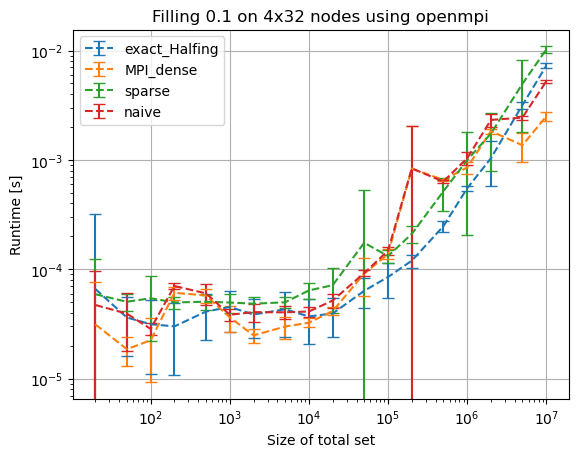

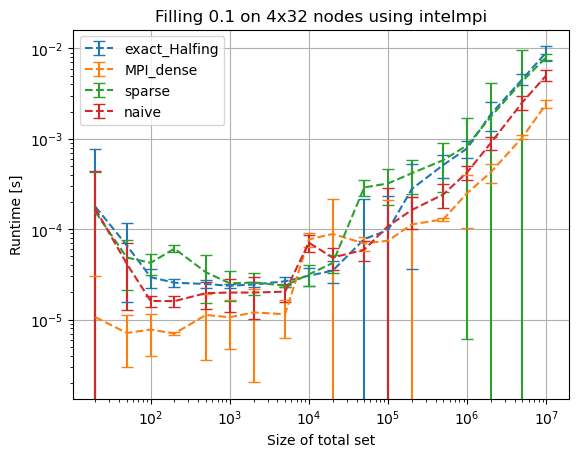

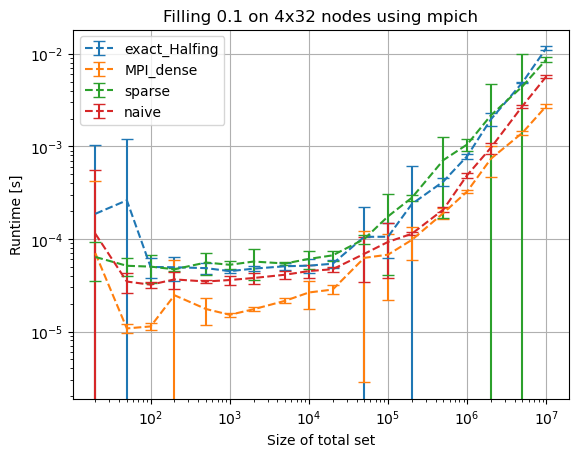

FileNotFoundError: [Errno 2] No such file or directory: 'data/performanceData/mpich/exect_Halfing_4x32_sizeSeries_0.100000.txt'

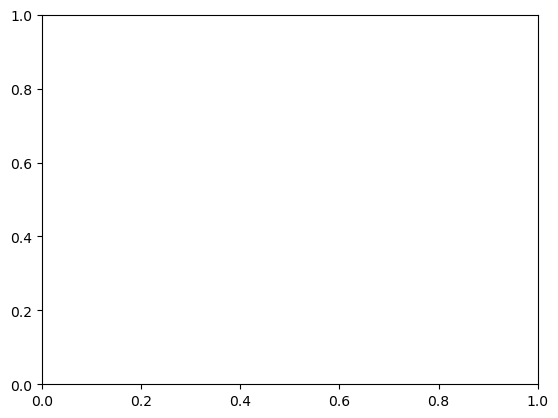

In [48]:
def plotSizeseries(ax, func, filling, nNodes, perNode, folder, label=""):


    fillingFloat = "{0:f}".format(filling)

    filepath = "data/performanceData/" + folder + "/" + func + "_" + str(nNodes) + "x" + str(perNode) +  "_sizeSeries_" + fillingFloat + ".txt"

    if label == "":
        label = func

    vertexSet, dense, sparse = parser(filepath)

    sizes, vals, errors = getMeanAndError(vertexSet)
    ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label=label)

    sizes, vals, errors = getMeanAndError(dense)
    ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label="MPI_dense")

    sizes, vals, errors = getMeanAndError(sparse)
    ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label="sparse")


def plotSizeseries_OnlyMain(ax, func, filling, nNodes, perNode, folder, label=""):


    fillingFloat = "{0:f}".format(filling)

    filepath = "data/performanceData/" + folder + "/" + func + "_" + str(nNodes) + "x" + str(perNode) +  "_sizeSeries_" + fillingFloat + ".txt"

    if label == "":
        label = func
        

    vertexSet, _, _ = parser(filepath)

    sizes, vals, errors = getMeanAndError(vertexSet)
    ax.errorbar(sizes, vals, ls="--", yerr=errors, capsize=4, label=label)




def plotShow(ax, filling, nNodes, perNode, folder, title=True, save=False):
    ax.set_xscale("log")
    ax.set_yscale("log")


    ax.grid()
    ax.set_xlabel("Size of total set")
    ax.set_ylabel("Runtime [s]")
    ax.legend()


    if title:
        plt.title("Filling {0} on {1}x{2} nodes using {3}".format(filling, nNodes, perNode, folder))

    if save:
        plt.savefig("./data/figs/sizeSeries.png")
    plt.show()


ax = plt.axes()
plotSizeseries(ax, "exact_Halfing", 0.1, 4, 32, "openmpi")
plotSizeseries_OnlyMain(ax, "naive", 0.1, 4, 32, "openmpi")
plotShow(ax, 0.1, 4, 32, "openmpi")

ax1 = plt.axes()
plotSizeseries(ax1, "exact_Halfing", 0.1, 4, 32, "intelmpi")
plotSizeseries_OnlyMain(ax1, "naive", 0.1, 4, 32, "intelmpi")
plotShow(ax1, 0.1, 4, 32, "intelmpi")

ax2 = plt.axes()
plotSizeseries(ax2, "exact_Halfing", 0.1, 4, 32, "mpich")
plotSizeseries_OnlyMain(ax2, "naive", 0.1, 4, 32, "mpich")
plotShow(ax2, 0.1, 4, 32, "mpich")





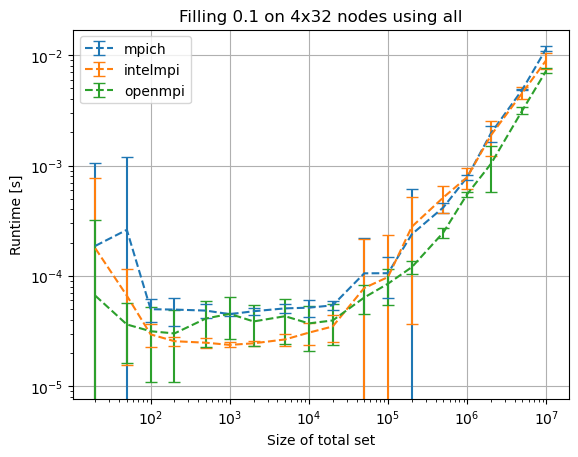

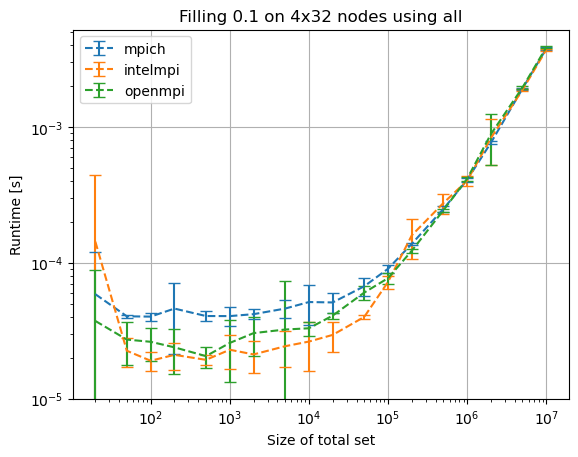

In [52]:
ax = plt.axes()
plotSizeseries_OnlyMain(ax, "exact_Halfing", 0.1, 4, 32, "mpich", "mpich")
plotSizeseries_OnlyMain(ax, "exact_Halfing", 0.1, 4, 32, "intelmpi", "intelmpi")
plotSizeseries_OnlyMain(ax, "exact_Halfing", 0.1, 4, 32, "openmpi", "openmpi")
plotShow(ax, 0.1, 4, 32, "all")

ax = plt.axes()
plotSizeseries_OnlyMain(ax, "dense", 0.1, 4, 32, "mpich", "mpich")
plotSizeseries_OnlyMain(ax, "dense", 0.1, 4, 32, "intelmpi", "intelmpi")
plotSizeseries_OnlyMain(ax, "dense", 0.1, 4, 32, "openmpi", "openmpi")
plotShow(ax, 0.1, 4, 32, "all")